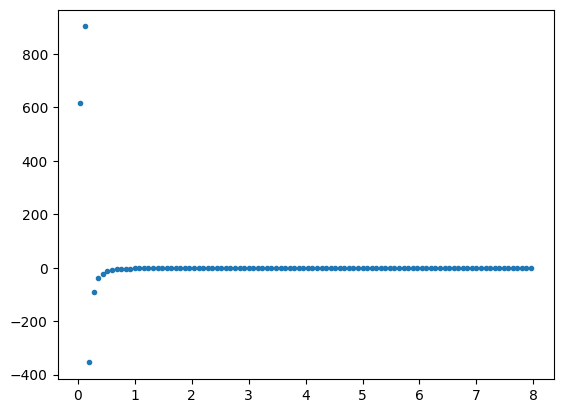

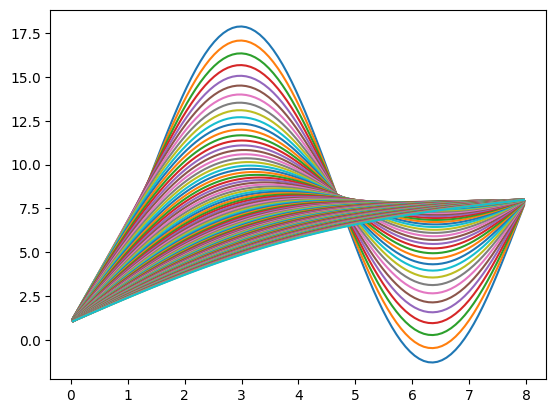

In [ ]:
from scipy.fftpack import dst, idst
from numpy import *
from matplotlib.pylab import *
L = 8        
N = 100
dx = L/(N)            # intervalle temporel entre deux points

A = 1
B = 8

#Fonction validant conditions aux limites
a = lambda x : A + x*(B-A)/L #dst
#a = lambda x : Ax + x**2*(B-A)/(2*L) #dct

#u = lambda x : exp(x/100)*(x)*(L-x) + a(x)
u = lambda x : sin(x*pi/5)*(x)*(L-x) + a(x)

#Changement de variable
v = lambda x : a(x)
w = lambda x : u(x) - v(x)

X = linspace(dx/2, L-dx/2, N)

lamb=(pi*arange(1,N+1)/L)**2
#lamb=(pi*(arange(1,N+1)-0.5)/L)**2 #dct
tfd0=dst(w(X))
plot(X,tfd0, '.')
plt.show()

for T in linspace(0,10,N) :
	uchapeauT=tfd0*exp(-lamb*T)
	uT=0.5*idst(uchapeauT)/N+v(X)
	plot(X,uT)

plt.show()


C:\Users\shawn\AppData\Local\Temp\ipykernel_21936\1053219472.py:11: RuntimeWarning: invalid value encountered in sqrt
  eq1 = ((x/7)**2*sqrt(abs(abs(x)-3)/(abs(x)-3))+(y/3)**2*sqrt(abs(y+3/7*sqrt(33))/(y+3/7*sqrt(33)))-1);
C:\Users\shawn\AppData\Local\Temp\ipykernel_21936\1053219472.py:12: RuntimeWarning: invalid value encountered in sqrt
  eq2 = (abs(x/2)-((3*sqrt(33)-7)/112)*x**2-3+sqrt(1-(abs(abs(x)-2)-1)**2)-y);
C:\Users\shawn\AppData\Local\Temp\ipykernel_21936\1053219472.py:13: RuntimeWarning: invalid value encountered in sqrt
  eq3 = (9*sqrt(abs((abs(x)-1)*(abs(x)-.75))/((1-abs(x))*(abs(x)-.75)))-8*abs(x)-y);
C:\Users\shawn\AppData\Local\Temp\ipykernel_21936\1053219472.py:14: RuntimeWarning: invalid value encountered in sqrt
  eq4 = (3*abs(x)+.75*sqrt(abs((abs(x)-.75)*(abs(x)-.5))/((.75-abs(x))*(abs(x)-.5)))-y);
C:\Users\shawn\AppData\Local\Temp\ipykernel_21936\1053219472.py:15: RuntimeWarning: invalid value encountered in sqrt
  eq5 = (2.25*sqrt(abs((x-.5)*(x+.5))/((.5-x)*(.5+x)

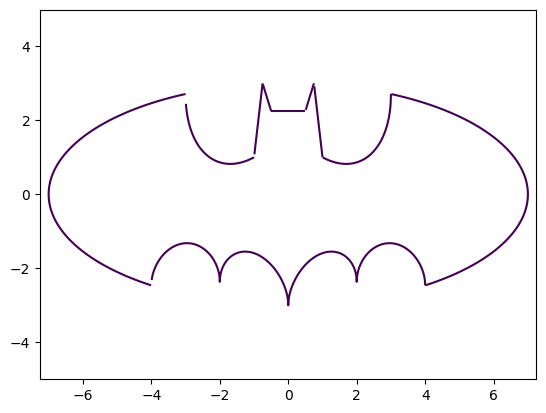

In [17]:

from __future__ import division
import matplotlib.pyplot as plt
from numpy import sqrt #originally had from scipy import sqrt
from numpy import meshgrid
from numpy import arange

xs = arange(-7.25, 7.25, 0.01);
ys = arange(-5, 5, 0.01);
x, y = meshgrid(xs, ys);

eq1 = ((x/7)**2*sqrt(abs(abs(x)-3)/(abs(x)-3))+(y/3)**2*sqrt(abs(y+3/7*sqrt(33))/(y+3/7*sqrt(33)))-1);
eq2 = (abs(x/2)-((3*sqrt(33)-7)/112)*x**2-3+sqrt(1-(abs(abs(x)-2)-1)**2)-y);
eq3 = (9*sqrt(abs((abs(x)-1)*(abs(x)-.75))/((1-abs(x))*(abs(x)-.75)))-8*abs(x)-y);
eq4 = (3*abs(x)+.75*sqrt(abs((abs(x)-.75)*(abs(x)-.5))/((.75-abs(x))*(abs(x)-.5)))-y);
eq5 = (2.25*sqrt(abs((x-.5)*(x+.5))/((.5-x)*(.5+x)))-y);
eq6 = (6*sqrt(10)/7+(1.5-.5*abs(x))*sqrt(abs(abs(x)-1)/(abs(x)-1))-(6*sqrt(10)/14)*sqrt(4-(abs(x)-1)**2)-y);

#eq1 = ((x/7.0)**2.0*sqrt(abs(abs(x)-3.0)/(abs(x)-3.0))+(y/3.0)**2.0*sqrt(abs(y+3.0/7.0*sqrt(33.0))/(y+3.0/7.0*sqrt(33.0)))-1.0)

for f in [eq1,eq2,eq3,eq4,eq5,eq6]:
    plt.contour(x, y, f, [0]);

plt.show();


C:\Users\shawn\AppData\Local\Temp\ipykernel_21936\778381573.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


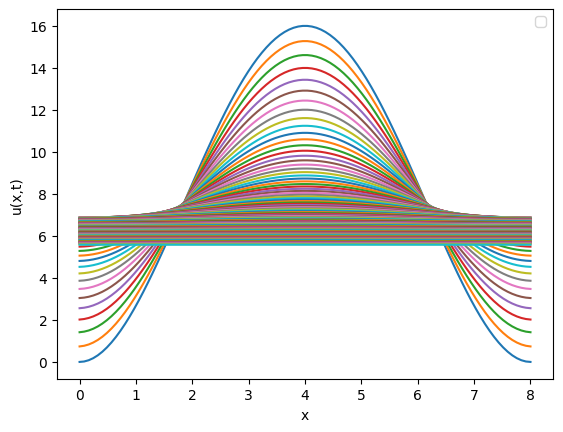

In [ ]:
import numpy as np
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt

# Paramètres
L = 8
N = 100
alpha = 1.0
dx = L / N
dt = 0.01
T_max = 10

# Fonction initiale (condition initiale u(x, 0) = f(x))
def f(x):
    return np.sin(np.pi * x / L) * (x) * (L - x)

# Points spatiaux
x = np.linspace(0, L, N)

# Conditions initiales
u = f(x)

# DCT-II de la condition initiale
u_hat = dct(u, type=2, norm='ortho')

# Valeurs propres
k = np.arange(N)
lambda_k = (np.pi * (k + 0.5) / L) ** 2

# Évolution temporelle
u_t = np.zeros((int(T_max / dt), N))
for i, t in enumerate(np.arange(0, T_max, dt)):
    u_hat_t = u_hat * np.exp(-alpha * lambda_k * t)
    u_t[i] = idct(u_hat_t, type=2, norm='ortho')

# Visualisation
for i in range(0, len(u_t), int(len(u_t) / 10)):
    plt.plot(x, u_t[i], label=f't={i*dt:.2f}')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.show()


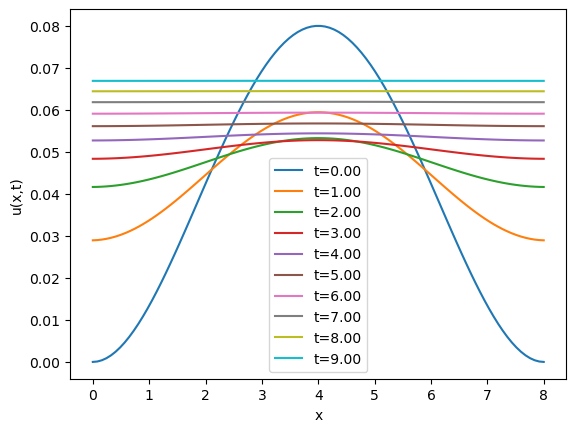

In [2]:
import numpy as np
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt

#F CONSTANT

# Paramètres
L = 8
N = 100
alpha = 1.0
dx = L / N
dt = 0.01
T_max = 10

# Fonction initiale (condition initiale u(x, 0) = g(x))
def g(x):
    return np.sin(np.pi * x / L) * (x) * (L - x)

# Terme source (second membre)
def f(x):
    return np.ones_like(x)  # Par exemple, une fonction constante

# Points spatiaux
x = np.linspace(0, L, N)

# Conditions initiales
u = g(x)

# DCT-II de la condition initiale
u_hat = dct(u, type=2, norm='ortho')

# DCT-II du terme source
f_hat = dct(f(x), type=2, norm='ortho')

# Valeurs propres
k = np.arange(N)
lambda_k = (np.pi * (k + 0.5) / L) ** 2

# Évolution temporelle
u_t = np.zeros((int(T_max / dt), N))
for i, t in enumerate(np.arange(0, T_max, dt)):
    # Coefficients Fourier au temps t
    u_hat_t = (u_hat * np.exp(-alpha * lambda_k * t) +
               f_hat * (1 - np.exp(-alpha * lambda_k * t)) / (alpha * lambda_k))
    # Transformée inverse pour obtenir u(x, t)
    u_t[i] = (idct(u_hat_t, type=2, norm='ortho'))*(1/(2*N))

# Visualisation
for i in range(0, len(u_t), int(len(u_t) / 10)):
    plt.plot(x, u_t[i], label=f't={i*dt:.2f}')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.show()


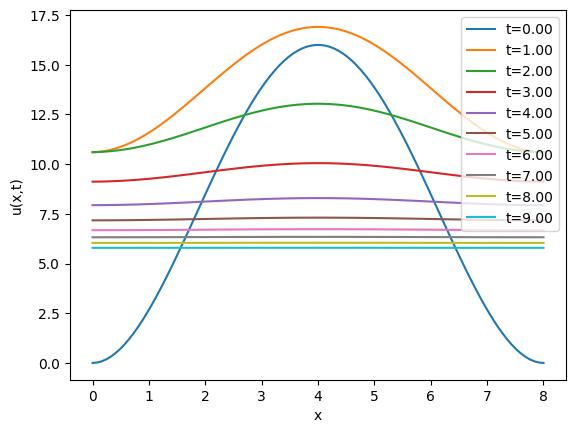

In [27]:
import numpy as np
from scipy.fftpack import dct, idct
import matplotlib.pyplot as plt

#F PAS CONSTANT

# Paramètres
L = 8
N = 100
alpha = 1.0
dx = L / N
dt = 0.01
T_max = 10

# Fonction initiale (condition initiale u(x, 0) = g(x))
def g(x):
    return np.sin(np.pi * x / L) * (x) * (L - x)

# Terme source (second membre)
def f(x, t):
    return np.sin(np.pi * x / L) * np.exp(-t)

# Points spatiaux
x = np.linspace(0, L, N)

# Conditions initiales
u = g(x)

# DCT-II de la condition initiale
u_hat = dct(u, type=2, norm='ortho')

# Valeurs propres
k = np.arange(N)
lambda_k = (np.pi * (k + 0.5) / L) ** 2

# Évolution temporelle
u_t = np.zeros((int(T_max / dt), N))
for i, t in enumerate(np.arange(0, T_max, dt)):
    # Calcul du terme source à l'instant t
    f_t = f(x, t)
    f_hat_t = dct(f_t, type=2, norm='ortho')
    
    # Coefficients Fourier au temps t
    if t == 0:
        u_hat_t = u_hat * np.exp(-alpha * lambda_k * t)
    else:
        u_hat_t = u_hat * np.exp(-alpha * lambda_k * t) + \
                  dt * np.sum([f_hat_t * np.exp(-alpha * lambda_k * (t - tau)) for tau in np.arange(0, t, dt)], axis=0) / alpha / lambda_k

    # Transformée inverse pour obtenir u(x, t)
    u_t[i] = idct(u_hat_t, type=2, norm='ortho')

# Visualisation
for i in range(0, len(u_t), int(len(u_t) / 10)):
    plt.plot(x, u_t[i], label=f't={i*dt:.2f}')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.show()
